# 📊 Pandas Data Preparation — Full Pipeline

This notebook walks through the complete data preparation workflow before feeding data into a machine learning model:

1. Load the dataset
2. Normalize column names & string values
3. Exploratory Data Analysis (EDA)
4. Handle skewed distributions (log transformation)
5. Handle missing values
6. Fix dtype issues
7. Feature importance with Mutual Information
8. Encode categorical variables

> **Why this order?** We explore and clean the data *before* any modelling. Feeding dirty data to a model produces unreliable results — garbage in, garbage out.

---
## 1. 📦 Imports

We only need `numpy`, `pandas`, `matplotlib`, and `sklearn.metrics` for this pipeline — no modelling libraries required at this stage.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#from sklearn.metrics import mutual_info_score   # only used for MI scoring, not modelling

%matplotlib inline
pd.set_option('display.max_columns', None)      # show all columns in previews
pd.set_option('display.float_format', '{:.2f}'.format)

print('✅ Ready')


✅ Ready


In [2]:


def mutual_info_score(x, y):
    x = np.asarray(x)
    y = np.asarray(y)

    if x.size != y.size:
        raise ValueError("x and y must have the same length")

    # Get unique labels
    x_labels, x_inv = np.unique(x, return_inverse=True)
    y_labels, y_inv = np.unique(y, return_inverse=True)

    # Build contingency table
    contingency = np.zeros((len(x_labels), len(y_labels)), dtype=np.float64)
    for i in range(x.size):
        contingency[x_inv[i], y_inv[i]] += 1

    # Convert to probabilities
    pxy = contingency / contingency.sum()
    px = pxy.sum(axis=1)
    py = pxy.sum(axis=0)

    # Compute mutual information
    nz = pxy > 0
    mi = np.sum(pxy[nz] * np.log(pxy[nz] / (px[:, None] * py[None, :])[nz]))

    return mi

---
## 2. 📥 Load the Dataset

You can load from a URL (using `wget`) or from a local file. Both options are shown below.

After loading, always do a quick **shape check** and preview the first few rows to make sure the file was read correctly (correct delimiter, no stray header rows, etc.).

In [4]:
# --- Option A: Download from a URL ---
# data = 'https://your-dataset-url.csv'
# !wget $data -O dataset.csv
# df = pd.read_csv('dataset.csv')

# --- Option B: Load a local file ---
# df = pd.read_csv('your_file.csv')

# ---- Demo: synthetic dataset (replace with your own) ----
np.random.seed(42)
n = 500
df = pd.DataFrame({
    'lead Number':   range(1, n + 1),
    'Lead Origin':   np.random.choice(['API', 'Landing Page Submission', 'Direct Traffic', None], n),
    'Lead Source':   np.random.choice(['Olark Chat', 'Organic Search', 'Direct Traffic', None], n),
    'Total Time Spent On Website': np.random.randint(0, 2000, n),
    'Total Visits':  np.random.randint(0, 30, n),
    'MSRP':          np.concatenate([
                         np.random.exponential(20000, n - 50),
                         np.random.exponential(200000, 50)
                     ]),
    'Total Charges': [
                         str(round(x, 2)) if np.random.rand() > 0.05 else ' '
                         for x in np.random.uniform(0, 5000, n)
                     ],
    'Status':        np.random.choice([0, 1, 2], n),
    'Churn':         np.random.choice([0, 1], n),
})

print(f'Rows: {df.shape[0]}  |  Columns: {df.shape[1]}')
df.head()

Rows: 500  |  Columns: 9


,lead Number,Lead Origin,Lead Source,Total Time Spent On Website,Total Visits,MSRP,Total Charges,Status,Churn
0,1,Direct Traffic,Direct Traffic,501,28,23908.21,301.34,1,0
1,2,None,Olark Chat,958,0,7057.90,4672.18,1,1
2,3,API,Olark Chat,1168,19,51644.97,1758.11,1,0
3,4,Direct Traffic,None,1224,29,70849.40,507.1,1,0
4,5,Direct Traffic,Direct Traffic,928,6,57743.47,2429.36,0,1


---
## 3. 🧹 Normalize Column Names & String Values

Inconsistent naming (spaces, capitals, mixed cases) causes subtle bugs when you reference columns by name. The fix is to **standardize everything** to `lower_case_with_underscores` — both column headers and the string values inside them.

We do this *once*, right after loading, so the rest of the notebook is consistent.

In [5]:
# --- 3a. Normalize column names ---
# Before: ['Lead Number', 'Lead Origin', 'Total Time Spent On Website', ...]
# After : ['lead_number', 'lead_origin', 'total_time_spent_on_website', ...]

print('Before:', df.columns.tolist())
df.columns = df.columns.str.lower().str.replace(' ', '_')
print('After :', df.columns.tolist())

Before: ['lead Number', 'Lead Origin', 'Lead Source', 'Total Time Spent On Website', 'Total Visits', 'MSRP', 'Total Charges', 'Status', 'Churn']
After : ['lead_number', 'lead_origin', 'lead_source', 'total_time_spent_on_website', 'total_visits', 'msrp', 'total_charges', 'status', 'churn']


In [6]:
# --- 3b. Normalize string values inside object columns ---
# We only loop over columns whose dtype is 'object' (i.e. text columns).
# Numeric columns are left untouched.

for col in df.dtypes[df.dtypes == 'object'].index:
    df[col] = df[col].str.lower().str.replace(' ', '_')

print('String columns after normalization:')
df.select_dtypes('object').head()

String columns after normalization:


,lead_origin,lead_source,total_charges
0,direct_traffic,direct_traffic,301.34
1,None,olark_chat,4672.18
2,api,olark_chat,1758.11
3,direct_traffic,None,507.1
4,direct_traffic,direct_traffic,2429.36


---
## 4. 🔍 Exploratory Data Analysis (EDA)

EDA is about **understanding the data before changing it**. We look at:
- Overall shape and types
- Unique values per column — columns with only 1 unique value are useless for a model
- Basic statistics to spot anomalies (impossible values, huge ranges, etc.)

> **Rule of thumb:** Start with numerical features first, then categorical ones.

In [31]:
# --- 4a. Dtypes overview ---
# This tells you which columns pandas read as numbers vs strings.
# Watch for numeric-looking columns (e.g. 'total_charges') that ended up as 'object'.
print(df.dtypes)
print()
print(f'Total nulls: {df.isnull().sum().sum()}')

lead_number                      int64
lead_origin                     object
lead_source                     object
total_time_spent_on_website      int64
total_visits                     int64
msrp                           float64
total_charges                   object
status                           int64
churn                            int64
dtype: object

Total nulls: 280


In [32]:
# --- 4b. Basic statistics ---
# For numerical columns: count, mean, std, min/max, quartiles.
# For object columns: count, unique, top (most frequent), freq.
df.describe(include='all')

,lead_number,lead_origin,lead_source,total_time_spent_on_website,total_visits,msrp,total_charges,status,churn
count,500.00,352,368,500.00,500.00,500.00,500,500.00,500.00
unique,NaN,3,3,NaN,NaN,NaN,478,NaN,NaN
top,NaN,direct_traffic,olark_chat,NaN,NaN,NaN,_,NaN,NaN
freq,NaN,122,136,NaN,NaN,NaN,23,NaN,NaN
mean,250.50,NaN,NaN,972.16,14.70,37295.27,NaN,0.96,0.47
std,144.48,NaN,NaN,600.81,8.71,67639.75,NaN,0.81,0.50
min,1.00,NaN,NaN,0.00,0.00,99.04,NaN,0.00,0.00
25%,125.75,NaN,NaN,471.50,7.00,6004.52,NaN,0.00,0.00
50%,250.50,NaN,NaN,909.00,15.50,17976.16,NaN,1.00,0.00
75%,375.25,NaN,NaN,1485.25,22.00,38211.93,NaN,2.00,1.00


In [33]:
# --- 4c. Unique values per column ---
# If nunique == 1  → constant column, zero information → safe to drop.
# If nunique == n  → likely an ID column, not useful as a feature.

cols_to_drop = []

for col in df.columns:
    n_unique = df[col].nunique()
    sample   = df[col].unique()[:5]
    flag     = '⚠️  DROP (zero variance)' if n_unique <= 1 else ''
    print(f'{col:40s}  nunique={n_unique:>5}   sample={sample}  {flag}')
    if n_unique <= 1:
        cols_to_drop.append(col)

if cols_to_drop:
    df.drop(columns=cols_to_drop, inplace=True)
    print(f'\nDropped: {cols_to_drop}')
else:
    print('\n✅ No zero-variance columns found.')

lead_number                               nunique=  500   sample=[1 2 3 4 5]  
lead_origin                               nunique=    3   sample=['direct_traffic' None 'api' 'landing_page_submission']  
lead_source                               nunique=    3   sample=['direct_traffic' 'olark_chat' None 'organic_search']  
total_time_spent_on_website               nunique=  431   sample=[ 501  958 1168 1224  928]  
total_visits                              nunique=   30   sample=[28  0 19 29  6]  
msrp                                      nunique=  500   sample=[23908.20913786  7057.8992949  51644.97342711 70849.39845245
 57743.47362482]  
total_charges                             nunique=  478   sample=['301.34' '4672.18' '1758.11' '507.1' '2429.36']  
status                                    nunique=    3   sample=[1 0 2]  
churn                                     nunique=    2   sample=[0 1]  

✅ No zero-variance columns found.


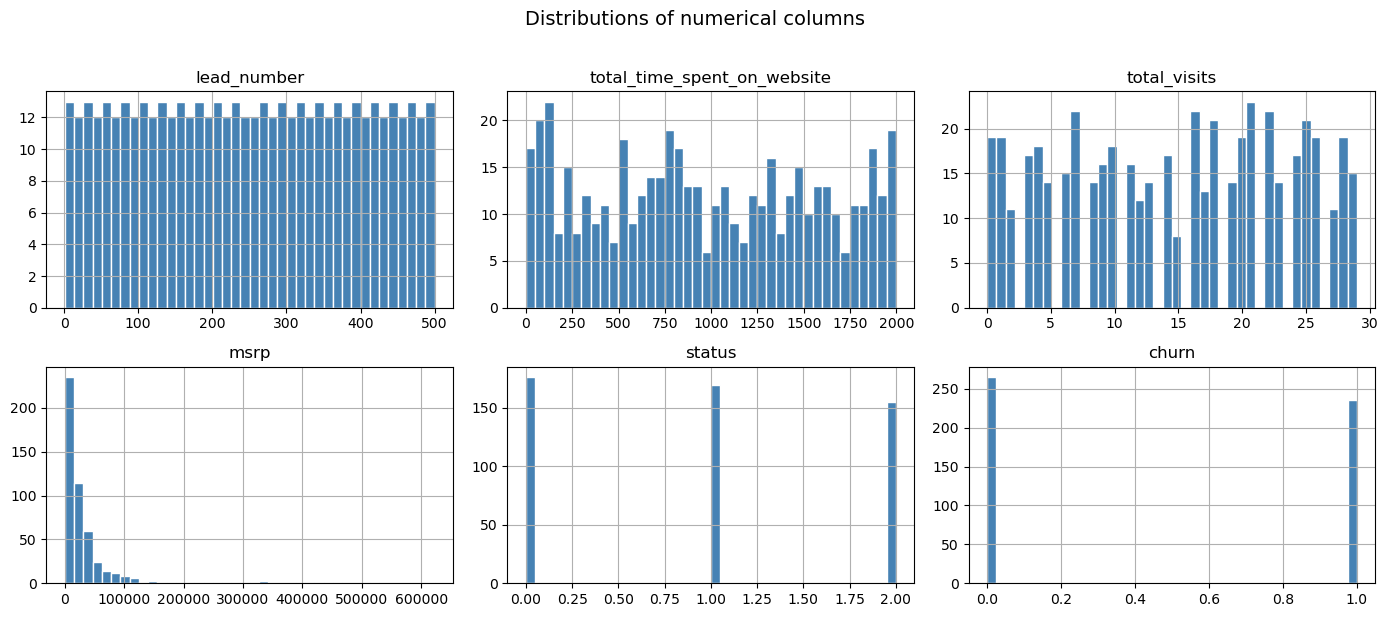

In [34]:
# --- 4d. Visualize numerical columns ---
# A histogram grid gives a quick overview of all numeric distributions at once.
# Long tails, bimodal shapes, or heavy spikes are all easy to spot here.

num_cols = df.select_dtypes('number').columns.tolist()

df[num_cols].hist(bins=40, figsize=(14, 6), layout=(2, -1), color='steelblue', edgecolor='white')
plt.suptitle('Distributions of numerical columns', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

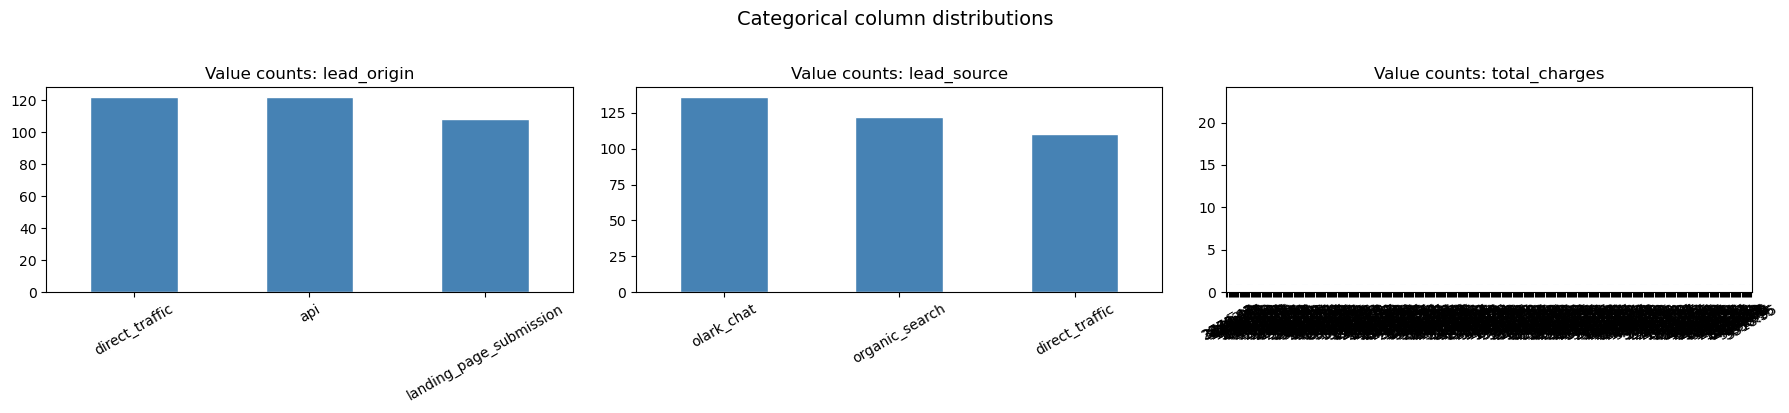

In [35]:
# --- 4e. Visualize categorical columns ---
# Value counts show which categories dominate.
# A very imbalanced category (one value is 95% of the data) adds little signal.

cat_cols = df.select_dtypes('object').columns.tolist()

fig, axes = plt.subplots(1, len(cat_cols), figsize=(6 * len(cat_cols), 4))
if len(cat_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, cat_cols):
    df[col].value_counts().plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'Value counts: {col}', fontsize=12)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Categorical column distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 5. 📈 Distribution Fix — Log Transformation

Many real-world features (prices, revenue, visit counts) follow a **long-tail distribution**: a few extreme values stretch the axis so far that most data gets squashed into a small region on the left. This confuses ML models because the extreme values dominate distance/error calculations.

**Solution:** apply `np.log1p()` (= log(x + 1)).
- The `+1` ensures it works even when the value is `0` (since log(0) = −∞).
- To reverse the transform later, use `np.expm1()`.

The result is a distribution that's much closer to a normal (bell) curve, which most models handle better.

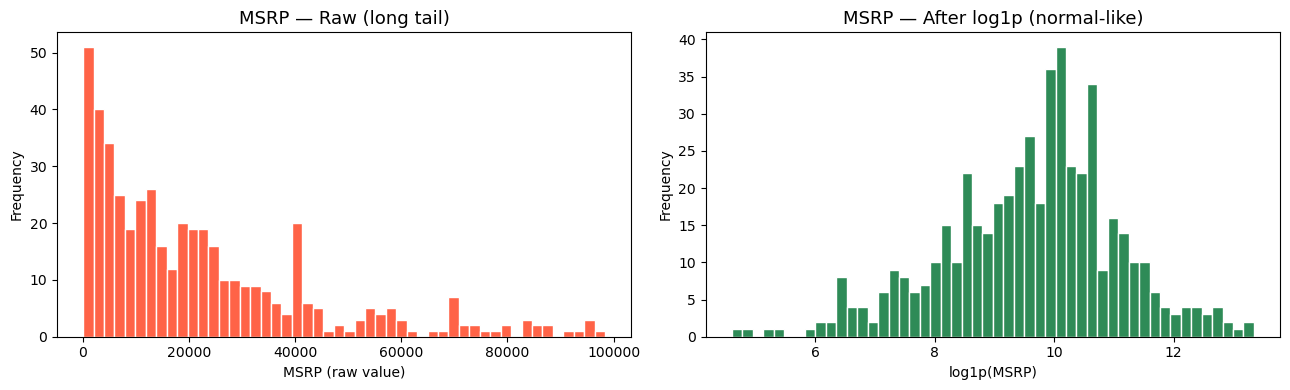

✅ log1p applied.  To reverse: np.expm1(df["msrp"])


In [36]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Before transform — long tail is clearly visible on the right
df['msrp'][df['msrp'] < 100_000].plot(
    kind='hist', bins=50, ax=axes[0], color='tomato', edgecolor='white'
)
axes[0].set_title('MSRP — Raw (long tail)', fontsize=13)
axes[0].set_xlabel('MSRP (raw value)')

# Apply the log transform in-place
df['msrp'] = np.log1p(df['msrp'])

# After transform — the distribution is now much more symmetric
df['msrp'].plot(
    kind='hist', bins=50, ax=axes[1], color='seagreen', edgecolor='white'
)
axes[1].set_title('MSRP — After log1p (normal-like)', fontsize=13)
axes[1].set_xlabel('log1p(MSRP)')

plt.tight_layout()
plt.show()

print('✅ log1p applied.  To reverse: np.expm1(df["msrp"])')

---
## 6. 🕳️ Missing Values

Most ML models **cannot handle NaN** — they raise an error or silently produce wrong results. We need to:
1. Identify where the nulls are and how many
2. Decide on a fill strategy

Common fill strategies:

| Column type | Strategy | Why |
|---|---|---|
| Numeric | Fill with `0` or **median** | Median is robust to outliers |
| Categorical | Fill with `'unknown'` | Preserves the fact that data was missing as a signal |
| Time-series | Forward-fill (`ffill`) | Uses the last known value |

In [37]:
# --- 6a. Count missing values per column ---
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_%': missing_pct
}).query('missing_count > 0').sort_values('missing_count', ascending=False)

if missing_df.empty:
    print('✅ No missing values found!')
else:
    print(missing_df)

             missing_count  missing_%
lead_origin            148      29.60
lead_source            132      26.40


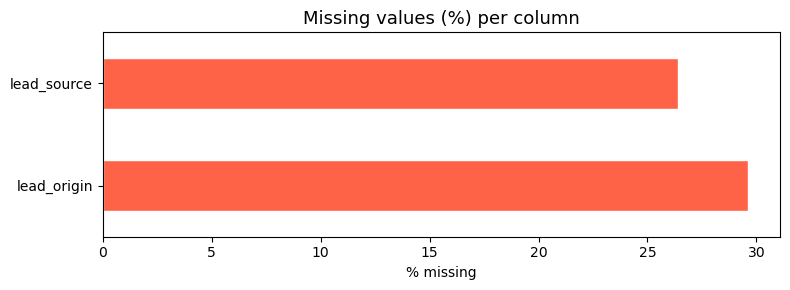

In [38]:
# --- 6b. Visualize missingness as a horizontal bar chart ---
# This makes it easy to see which columns need attention at a glance.

if not missing_df.empty:
    missing_df['missing_%'].plot(
        kind='barh',
        figsize=(8, max(3, len(missing_df) * 0.5)),
        color='tomato', edgecolor='white'
    )
    plt.title('Missing values (%) per column', fontsize=13)
    plt.xlabel('% missing')
    plt.tight_layout()
    plt.show()

In [39]:
# --- 6c. Fill missing values ---
# Numeric  → median  (more robust than mean when outliers exist)
# Categorical → 'unknown'  (we keep the missingness as a signal for the model)

num_cols = df.select_dtypes(include='number').columns
cat_cols = df.select_dtypes(include='object').columns

df[num_cols] = df[num_cols].fillna(df[num_cols].median())
df[cat_cols] = df[cat_cols].fillna('unknown')

print(f'Missing values remaining: {df.isnull().sum().sum()}')
print('✅ All nulls handled.')

Missing values remaining: 0
✅ All nulls handled.


---
## 7. 🔧 Fix dtype Issues — Object → Numeric

Sometimes a numeric column like `total_charges` is read as `object` (string) because the raw data contained blank strings, spaces, or text like `"N/A"`. Pandas cannot parse these as numbers, so it defaults the whole column to `object`.

**Fix:** use `pd.to_numeric(..., errors='coerce')` which silently turns unparseable entries into `NaN`, then fill those with `0`.

> `errors='coerce'` is safer than `errors='raise'` (which crashes) and `errors='ignore'` (which silently keeps the bad value as a string).

In [40]:
print('dtype before fix:', df['total_charges'].dtype)
print('Sample values   :', df['total_charges'].unique()[:8])

dtype before fix: object
Sample values   : ['301.34' '4672.18' '1758.11' '507.1' '2429.36' '1283.88' '1424.36'
 '1536.45']


In [41]:
# errors='coerce' → anything that cannot be converted becomes NaN
df['total_charges'] = pd.to_numeric(df['total_charges'], errors='coerce')

# Replace the resulting NaNs with 0
df['total_charges'] = df['total_charges'].fillna(0)

print('dtype after fix :', df['total_charges'].dtype)
df['total_charges'].describe()

dtype after fix : float64


count    500.00
mean    2357.02
std     1498.31
min        0.00
25%     1010.47
50%     2405.79
75%     3664.35
max     4991.74
Name: total_charges, dtype: float64

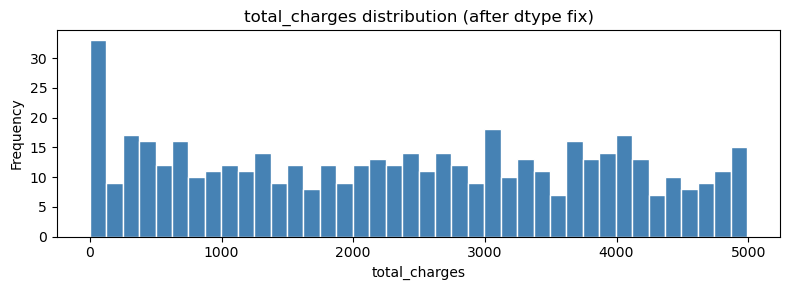

In [42]:
# Quick distribution check after the fix
df['total_charges'].plot(
    kind='hist', bins=40, figsize=(8, 3),
    color='steelblue', edgecolor='white',
    title='total_charges distribution (after dtype fix)'
)
plt.xlabel('total_charges')
plt.tight_layout()
plt.show()

---
## 8. 🤝 Feature Importance — Mutual Information

Before building a model we want to know **which features are most informative** about the target variable (`churn`). Mutual Information (MI) measures how much knowing a feature reduces uncertainty about the target.

- **MI = 0** → feature and target are independent — the feature adds no signal
- **Higher MI** → stronger relationship with the target — worth keeping

We compute MI for **categorical** features. For numerical features, the **correlation matrix** serves a similar purpose — it shows which features move together (and can reveal multicollinearity).

In [43]:
# Identify column types on the current dataframe
categorical = df.select_dtypes('object').columns.tolist()
numerical   = df.select_dtypes('number').columns.tolist()

print('Categorical features:', categorical)
print('Numerical features  :', numerical)

Categorical features: ['lead_origin', 'lead_source']
Numerical features  : ['lead_number', 'total_time_spent_on_website', 'total_visits', 'msrp', 'total_charges', 'status', 'churn']


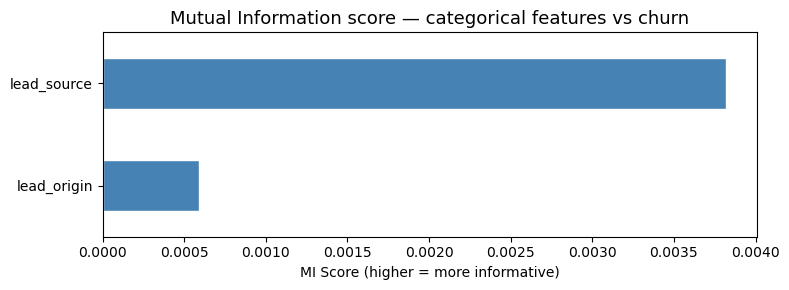


Full ranking (descending):
lead_source   0.00
lead_origin   0.00
dtype: float64


In [44]:
# --- 8a. Mutual Information for categorical features ---
TARGET = 'churn'

def mutual_info_churn_score(series):
    """Return the MI score between a categorical series and the target column."""
    return mutual_info_score(series, df[TARGET])

if categorical:
    mi = df[categorical].apply(mutual_info_churn_score)
    mi = mi.sort_values(ascending=True)   # ascending so highest bar appears at the top

    mi.plot(
        kind='barh',
        figsize=(8, max(3, len(mi) * 0.6)),
        color='steelblue', edgecolor='white'
    )
    plt.title('Mutual Information score — categorical features vs churn', fontsize=13)
    plt.xlabel('MI Score (higher = more informative)')
    plt.tight_layout()
    plt.show()

    print('\nFull ranking (descending):')
    print(mi.sort_values(ascending=False))
else:
    print('No categorical columns to score.')

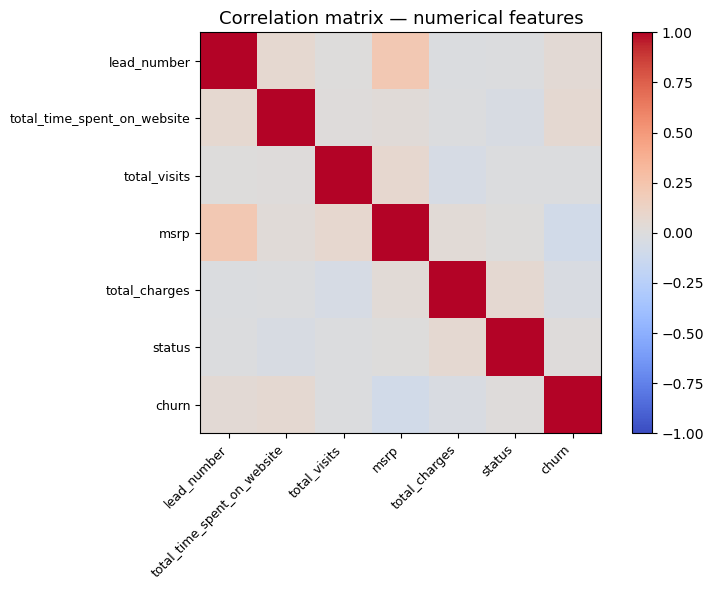

In [20]:
# --- 8b. Correlation matrix for numerical features ---
# Values close to +1 or -1 → strong linear relationship.
# Two features that are highly correlated with *each other* (not the target)
# are redundant — you usually only need one of them.

corr = df[numerical].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(corr.columns, fontsize=9)
ax.set_title('Correlation matrix — numerical features', fontsize=13)
plt.tight_layout()
plt.show()

---
## 9. 🏷️ Encode Categorical Variables

ML models need **numbers**, not strings. There are two steps here:

### Step A — Fix integer-coded categoricals with `map()`
A column like `status` might contain `0, 1, 2` but these integers are **not** ordinal (2 is not "twice as much" as 1). If we leave them as integers, the model treats them as a continuous scale, which is wrong.

Fix: `map()` them to meaningful string labels so the next step (one-hot encoding) handles them correctly.

### Step B — One-hot encoding with `get_dummies()`
One-hot encoding turns each category into its own binary column (`0` or `1`). This lets the model treat categories as independent possibilities rather than an ordered scale.

Example: `lead_origin` with values `['api', 'organic', 'direct']` becomes three columns:
```
lead_origin_api  |  lead_origin_organic  |  lead_origin_direct
       1         |           0           |          0
```

status before mapping: [0, 1, 2]
status after mapping : ['ok' 'unk' 'default']


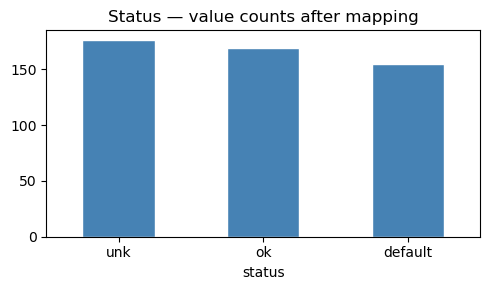

In [21]:
# --- 9a. Map integer-coded categorical to meaningful labels ---
# Without this, the model would think status=2 is "twice as important" as status=1.

print('status before mapping:', sorted(df['status'].unique()))

df['status'] = df['status'].map({0: 'unk', 1: 'ok', 2: 'default'})

print('status after mapping :', df['status'].unique())

df['status'].value_counts().plot(
    kind='bar', figsize=(5, 3), color='steelblue',
    edgecolor='white', title='Status — value counts after mapping'
)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [22]:
# --- 9b. One-hot encoding with pd.get_dummies() ---
# Each unique category value becomes a new binary (0/1) column.
# drop_first=False keeps all categories — better for interpretability.

cat_to_encode = df.select_dtypes('object').columns.tolist()
print(f'Columns to encode: {cat_to_encode}')

df_encoded = pd.get_dummies(df, columns=cat_to_encode, drop_first=False)

print(f'\nShape before encoding: {df.shape}')
print(f'Shape after  encoding: {df_encoded.shape}')
df_encoded.head(3)

Columns to encode: ['lead_origin', 'lead_source', 'status']

Shape before encoding: (500, 9)
Shape after  encoding: (500, 17)


,lead_number,total_time_spent_on_website,total_visits,msrp,total_charges,churn,lead_origin_api,lead_origin_direct_traffic,lead_origin_landing_page_submission,lead_origin_unknown,lead_source_direct_traffic,lead_source_olark_chat,lead_source_organic_search,lead_source_unknown,status_default,status_ok,status_unk
0,1,501,28,10.082019,301.34,0,False,True,False,False,True,False,False,False,False,True,False
1,2,958,0,8.862044,4672.18,1,False,False,False,True,False,True,False,False,False,True,False
2,3,1168,19,10.852168,1758.11,0,True,False,False,False,False,True,False,False,False,True,False


---
## 10. ✅ Final Sanity Check

Before handing the data off to a model, always verify:
- No remaining `NaN` values
- All columns are numeric (no remaining `object` columns)
- The shape looks right (reasonable number of rows and features)

In [23]:
print('=== Final checks ===')
print(f'Shape           : {df_encoded.shape}')
print(f'Missing values  : {df_encoded.isnull().sum().sum()}')
print(f'\nDtype counts:')
print(df_encoded.dtypes.value_counts())
print()
df_encoded.describe()

=== Final checks ===
Shape           : (500, 17)
Missing values  : 0

Dtype counts:
bool       11
int64       4
float64     2
Name: count, dtype: int64



,lead_number,total_time_spent_on_website,total_visits,msrp,total_charges,churn
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,250.500000,972.162000,14.702000,9.601708,2357.020960,0.470000
std,144.481833,600.811552,8.713498,1.455961,1498.309999,0.499599
min,1.000000,0.000000,0.000000,4.605615,0.000000,0.000000
25%,125.750000,471.500000,7.000000,8.700429,1010.467500,0.000000
50%,250.500000,909.000000,15.500000,9.796857,2405.790000,0.000000
75%,375.250000,1485.250000,22.000000,10.550917,3664.347500,1.000000
max,500.000000,1997.000000,29.000000,13.341596,4991.740000,1.000000


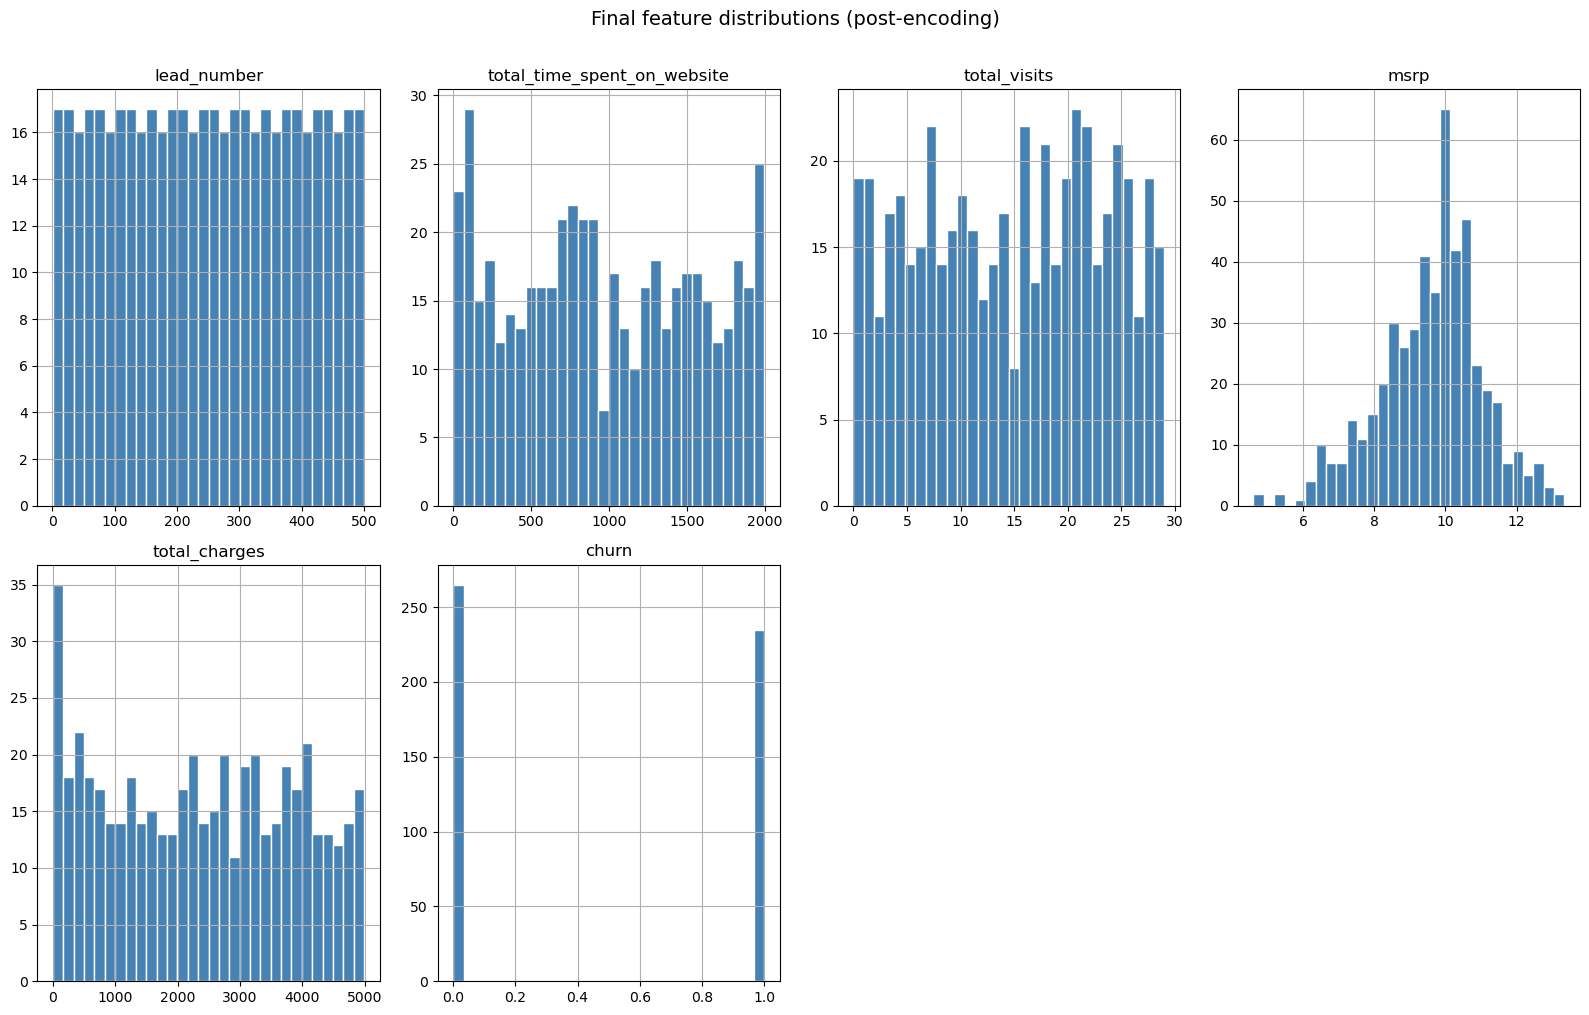


✅ Dataset is clean and ready for modelling!


In [24]:
# Final overview histogram of all features after encoding
df_encoded.hist(
    bins=30, figsize=(16, 10), layout=(-1, 4),
    color='steelblue', edgecolor='white'
)
plt.suptitle('Final feature distributions (post-encoding)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print('\n✅ Dataset is clean and ready for modelling!')

---
## 📌 Quick-Reference Cheatsheet

| Task | Code | Notes |
|---|---|---|
| Normalize column names | `df.columns = df.columns.str.lower().str.replace(' ', '_')` | Do this right after loading |
| Normalize string values | `df[col] = df[col].str.lower().str.replace(' ', '_')` | Loop over `object` columns only |
| Unique value counts | `df[col].nunique()` / `.unique()[:5]` | Drop columns with `nunique == 1` |
| Histogram grid | `df.hist(bins=40, figsize=(14,6))` | Great first numerical overview |
| Category bar chart | `df[col].value_counts().plot(kind='bar')` | Spot imbalanced categories |
| Log transform | `np.log1p(df.col)` | Fixes long-tail; reverse with `np.expm1()` |
| Missing values | `df.isnull().sum()` | Then `fillna(median)` or `fillna('unknown')` |
| Fix string-numeric col | `pd.to_numeric(df.col, errors='coerce').fillna(0)` | Blank/error cells → NaN → 0 |
| Map integer categories | `df.col.map({0:'unk', 1:'ok', 2:'default'})` | Prevents model treating them as ordinal |
| Mutual Information | `mutual_info_score(series, target)` | Higher = more informative feature |
| Correlation matrix | `df.corr()` | Spot multicollinearity between numerics |
| One-hot encode | `pd.get_dummies(df, columns=[...])` | Converts strings to 0/1 binary columns |